# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|Mahardika Indra Pratama Ilyasa | 5054251045 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

'''

data = pd.read_csv('namafile.csv')
data.head()
data.info()
data.describe()

! Cari fungsi-fungsi yang dapat digunakan untuk menampilkan informasi yang diinginkan.

'''
data = pd.read_csv("WineQT.csv")

print("-== 5 Baris Pertama ==-")
display(data.head())

print("\n-== Info Dataset ==-")
data.info()

print("\n-== Statistik Deskriptif ==-")
display(data.describe().T)

# Cek dimensi dan missing value
print(f"\nJumlah Baris & Kolom: {data.shape}")
print(f"Total Missing Values:\n{data.isnull().sum()}")

-== 5 Baris Pertama ==-


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4



-== Info Dataset ==-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB

-== Statistik Deskriptif ==-


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000



Jumlah Baris & Kolom: (1143, 13)
Total Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


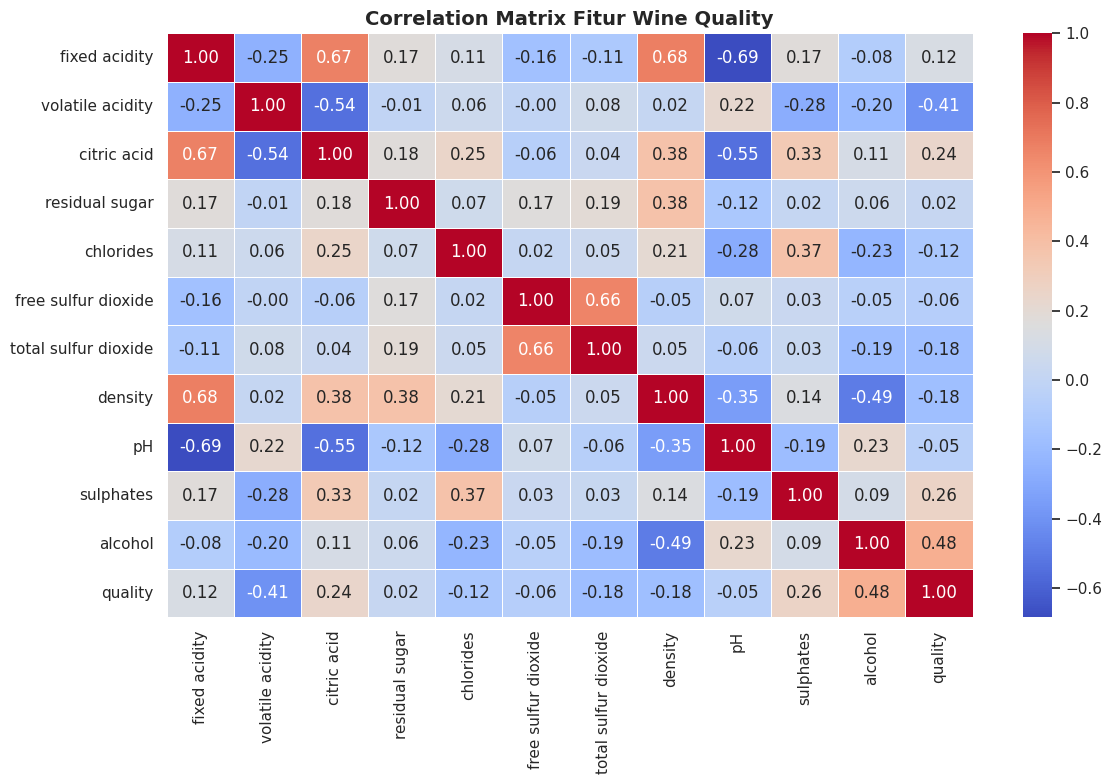

In [ ]:
# Tampilkan Korelasi Matrix
plt.figure(figsize=(12, 8))
# Kolom 'Id' tidak relevan untuk korelasi fitur
corr_data = data.drop(columns=["Id"]) if "Id" in data.columns else data
correlation_matrix = corr_data.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True,
)
plt.title("Correlation Matrix Fitur Wine Quality", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

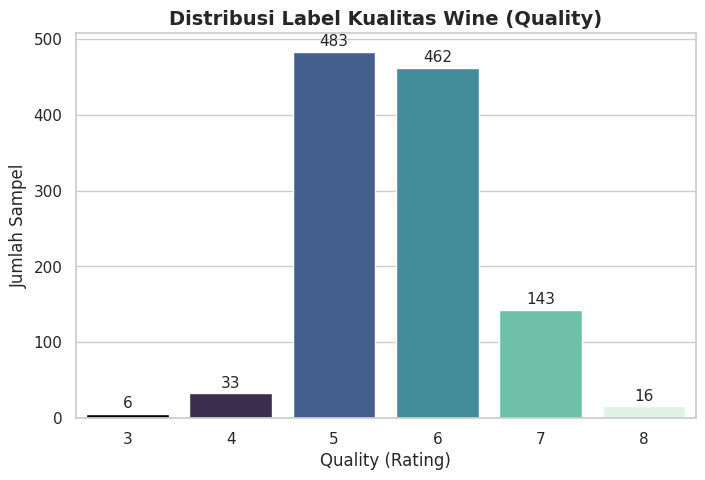

Persentase Sebaran Label (%):
 quality
5    42.26
6    40.42
7    12.51
4     2.89
8     1.40
3     0.52
Name: proportion, dtype: float64


In [ ]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=data, x="quality", hue="quality", palette="mako", legend=False
)
#Generate graph
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="baseline",
        fontsize=11,
        xytext=(0, 4),
        textcoords="offset points",
    )

plt.title("Distribusi Label Kualitas Wine (Quality)", fontsize=14, fontweight="bold")
plt.xlabel("Quality (Rating)")
plt.ylabel("Jumlah Sampel")
plt.show()

# Persentase sebaran kelas
print(
    "Persentase Sebaran Label (%):\n",
    (data["quality"].value_counts(normalize=True) * 100).round(2),
)

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan.

# **Kenapa saya memilih EDA INI?**
Analisis awal dilakukan untuk memahami karakteristik dataset sebelum preprocessing dan pemodelan. `head()` dan `info()` digunakan untuk melihat struktur dan tipe data, sedangkan `describe()` untuk melihat statistik deskriptif. Selain itu, dimensi dataset dan missing value diperiksa untuk mengetahui ukuran data dan kebutuhan preprocessing.

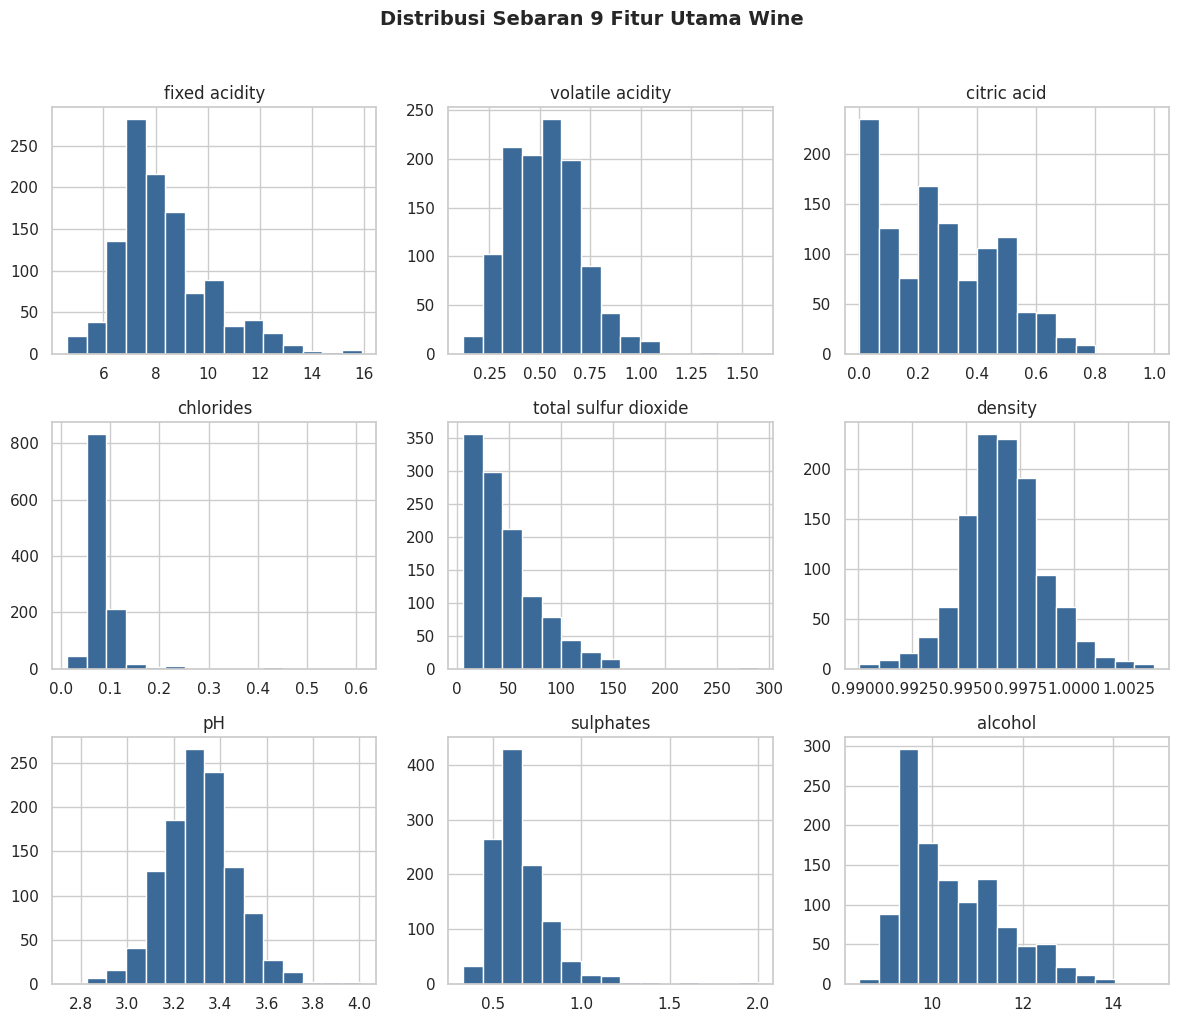

In [ ]:
# Daftar fitur
fitur_pilihan = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "chlorides",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
]

# Tampilkan histogram
data[fitur_pilihan].hist(
    figsize=(12, 10),
    layout=(3, 3),
    bins=15,
    color="#3b6998",
    edgecolor="white",
)
plt.suptitle(
    "Distribusi Sebaran 9 Fitur Wine",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

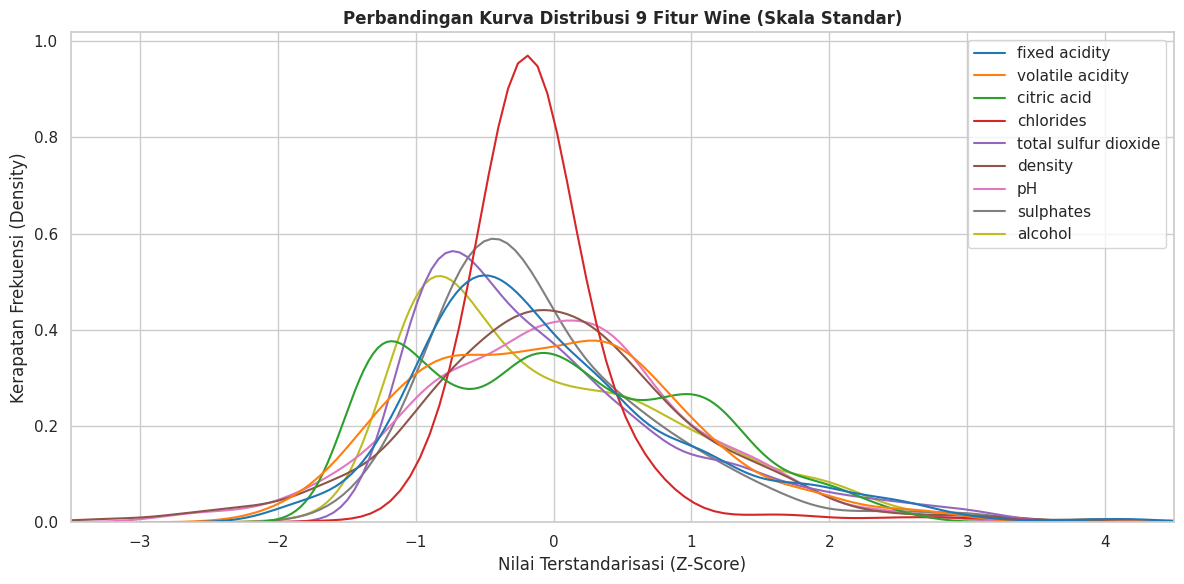

In [ ]:
data_scaled = pd.DataFrame(
    StandardScaler().fit_transform(data[fitur_pilihan]), columns=fitur_pilihan
)

# Gambar semua garis kurva
plt.figure(figsize=(12, 6))
sns.kdeplot(data=data_scaled, palette="tab10", common_norm=False)

plt.title(
    "Perbandingan Kurva Distribusi 9 Fitur Wine (Skala Standar)",
    fontweight="bold",
)
plt.xlabel("Nilai Terstandarisasi (Z-Score)")
plt.ylabel("Kerapatan Frekuensi (Density)")
plt.xlim(-3.5, 4.5)
plt.tight_layout()
plt.show()

# 2. Preprocessing




In [ ]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
# Drop kolom 'Id' karena hanya identifier baris
if "Id" in data.columns:
    data = data.drop(columns=["Id"])
    print("Kolom 'Id' berhasil dihapus.")

# Cek & tangani missing values
if data.isnull().sum().sum() > 0:
    data = data.dropna()
    print("Missing values telah di-drop.")
else:
    print("Tidak ditemukan missing value pada dataset.")

# Cek duplikasi baris
duplicate_count = data.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")

# Hapus duplikat
data = data.drop_duplicates().reset_index(drop=True)
print(f"Dimensi data setelah pembersihan duplikat: {data.shape}")

Kolom 'Id' berhasil dihapus.
Tidak ditemukan missing value pada dataset.
Jumlah baris duplikat: 125
Dimensi data setelah pembersihan duplikat: (1018, 12)


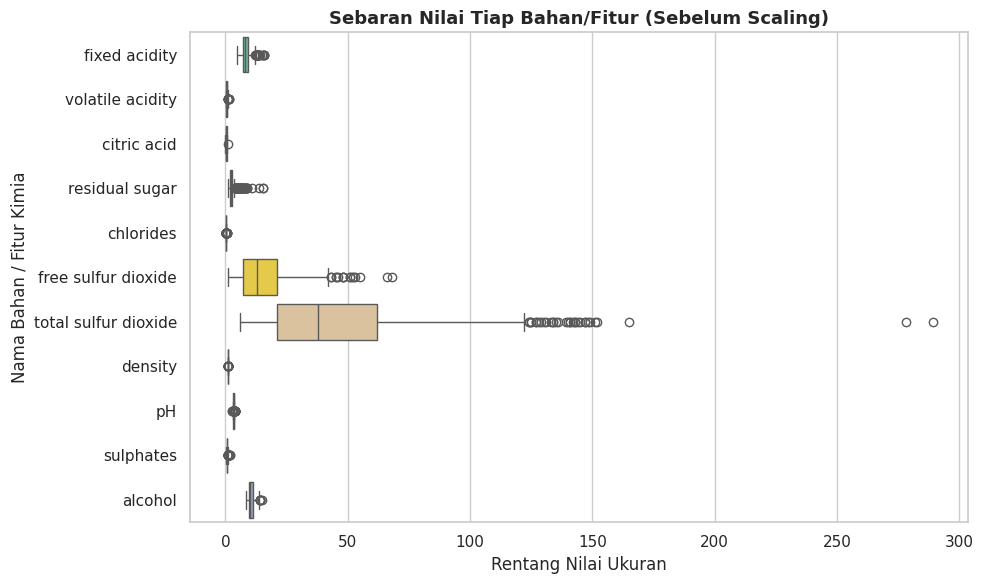

In [ ]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
# Visualisasi boxplot untuk memeriksa sebaran dan outlier fitur
plt.figure(figsize=(10, 6))
features = data.drop(columns=['quality']).columns

sns.boxplot(data=data[features], orient='h', palette='Set2')
plt.title(
    'Sebaran Nilai Tiap Bahan/Fitur (Sebelum Scaling)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Rentang Nilai Ukuran')
plt.ylabel('Nama Bahan / Fitur Kimia')
plt.tight_layout()
plt.show()

In [ ]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.
# Menentukan fitur yang minim kontribusi (noise) untuk dibuang
fitur_dibuang = ["quality", "residual sugar", "free sulfur dioxide"]

# Split fitur (X) dan label (y)
X = data.drop(columns=fitur_dibuang, errors="ignore")
y = data["quality"]

# Bagi dataset menjadi Train dan Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Lakukan Scaling pada fitur yang tersisa
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Fitur yang digunakan ({X.shape[1]} fitur): {list(X.columns)}")
print(f"Jumlah data latih: {X_train_scaled.shape[0]} baris")
print(f"Jumlah data uji   : {X_test_scaled.shape[0]} baris")

Fitur yang digunakan (9 fitur): ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Jumlah data latih: 814 baris
Jumlah data uji   : 204 baris


# 3. Eksperimen Model KNN


In [ ]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.
k_values = [3, 5, 7, 9, 11, 15, 17, 21]
distance_metrics = ["euclidean", "manhattan"]
experiment_results = []
trained_models = {}

for metric in distance_metrics:
    for k in k_values:
        model_key = f"{metric}_k{k}"
# Tambahkan weights='distance'
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights='distance')
        knn.fit(X_train_scaled, y_train)

        # Prediksi
        train_pred = knn.predict(X_train_scaled)
        test_pred = knn.predict(X_test_scaled)

        # Evaluasi
        acc_train = accuracy_score(y_train, train_pred)
        acc_test = accuracy_score(y_test, test_pred)
        f1_test_macro = f1_score(
            y_test, test_pred, average="macro", zero_division=0
        )
        f1_test_weighted = f1_score(
            y_test, test_pred, average="weighted", zero_division=0
        )

        experiment_results.append(
            {
                "Distance Metric": metric,
                "k": k,
                "Train Accuracy": round(acc_train, 4),
                "Test Accuracy": round(acc_test, 4),
                "F1-Score (Macro)": round(f1_test_macro, 4),
                "F1-Score (Weighted)": round(f1_test_weighted, 4),
            }
        )

        trained_models[model_key] = (knn, test_pred)

# Tampilkan perbandingan seluruh eksperimen
df_results = pd.DataFrame(experiment_results)
display(
    df_results.sort_values(
        by=["Test Accuracy", "F1-Score (Weighted)"], ascending=False
    ).reset_index(drop=True)
)

,Distance Metric,k,Train Accuracy,Test Accuracy,F1-Score (Macro),F1-Score (Weighted)
0,euclidean,21,1.0,0.6225,0.3013,0.6050
1,manhattan,21,1.0,0.6078,0.2955,0.5906
2,euclidean,15,1.0,0.5833,0.2824,0.5698
3,euclidean,17,1.0,0.5784,0.2807,0.5633
4,manhattan,17,1.0,0.5784,0.2845,0.5631
5,manhattan,11,1.0,0.5588,0.2715,0.5481
6,manhattan,15,1.0,0.5539,0.2738,0.5422
7,euclidean,11,1.0,0.5441,0.2598,0.5310
8,euclidean,7,1.0,0.5392,0.2668,0.5316
9,euclidean,3,1.0,0.5343,0.2922,0.5323


# 4. Evaluasi Model


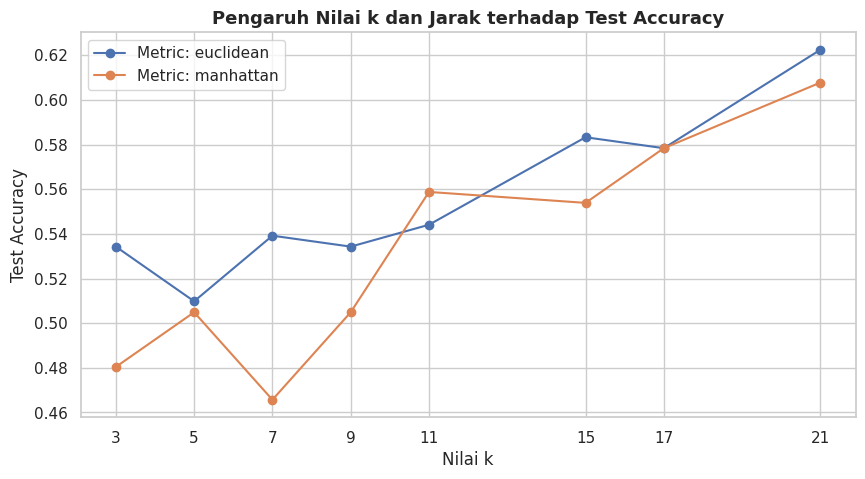

=== MODEL TERBAIK: Euclidean (k = 21) ===
Test Accuracy: 62.25%

Classification Report:

              precision    recall  f1-score   support

           3     0.0000    0.0000    0.0000         1
           4     0.0000    0.0000    0.0000         7
           5     0.7045    0.7126    0.7086        87
           6     0.5684    0.6585    0.6102        82
           7     0.5238    0.4583    0.4889        24
           8     0.0000    0.0000    0.0000         3

    accuracy                         0.6225       204
   macro avg     0.2995    0.3049    0.3013       204
weighted avg     0.5906    0.6225    0.6050       204



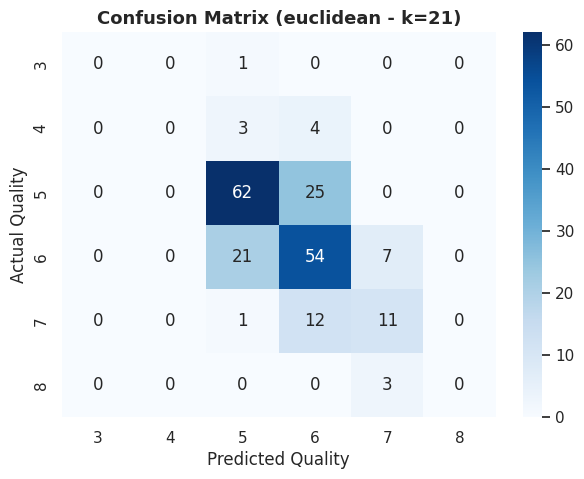

In [ ]:
# Plot Perbandingan Akurasi Antar Parameter
plt.figure(figsize=(10, 5))
for metric in distance_metrics:
    subset = df_results[df_results["Distance Metric"] == metric]
    plt.plot(
        subset["k"],
        subset["Test Accuracy"],
        marker="o",
        label=f"Metric: {metric}",
    )

plt.title(
    "Pengaruh Nilai k dan Jarak terhadap Test Accuracy",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Nilai k")
plt.ylabel("Test Accuracy")
plt.xticks(k_values)
plt.legend()
plt.show()

# Ambil model dengan performa terbaik
best_row = df_results.sort_values(
    by=["Test Accuracy", "F1-Score (Weighted)"], ascending=False
).iloc[0]
best_key = f"{best_row['Distance Metric']}_k{best_row['k']}"
best_model, best_pred = trained_models[best_key]

print(
    f"=== MODEL TERBAIK: {best_row['Distance Metric'].capitalize()} (k = {best_row['k']}) ==="
)
print(f"Test Accuracy: {best_row['Test Accuracy'] * 100:.2f}%")
print("\nClassification Report:\n")
print(
    classification_report(y_test, best_pred, zero_division=0, digits=4)
)

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
labels = np.unique(y_test)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.title(
    f"Confusion Matrix ({best_row['Distance Metric']} - k={best_row['k']})",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

### **Laporan Praktikum**

**Bab:**

1. EDA
2. Preprocessing
3. Eksperimen Model KNN
4. Evaluasi Model

---

### Bab 1. EDA

#### Bab 1.1 Deskripsi Awal Data

Dataset yang digunakan berasal dari *Wine Quality Dataset* (file `WineQT.csv`) yang mencatat pengukuran fisikokimia dari sampel varian anggur merah. Dataset ini memiliki ukuran **1.143 baris dan 13 kolom**, yang terdiri atas:

* 11 atribut prediktor fitur fisikokimia: `fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, dan `alcohol`.


* 1 atribut identifikasi baris: `Id`.


* 1 variabel target/luaran: `quality` (skala penilaian sensorik bertipe integer dengan nilai diskret mulai dari 3 hingga 8).



Pemeriksaan awal melalui `data.info()` dan `data.isnull().sum()` mengonfirmasi bahwa seluruh nilai pada 11 atribut fisikokimia bertipe *float64*, tidak ditemukan adanya nilai kosong (*missing values/NaN*), serta atribut `Id` murni berfungsi sebagai penomoran baris tanpa nilai prediktif kimiawi.

#### Bab 1.2 Penjelajahan Data

Berdasarkan visualisasi diagram batang (`sns.countplot`), distribusi label target `quality` terbukti mengalami **ketidakseimbangan kelas (*class imbalance*)** yang signifikan:

* Lebih dari **82%** sampel terakumulasi pada dua rating kualitas penengah, yaitu kualitas **5** sebanyak 483 data (42,26%) dan kualitas **6** sebanyak 462 data (40,42%).


* Kategori ekstrem memiliki proporsi sangat rendah: kualitas **7** (143 data / 12,51%), kualitas **4** (33 data / 2,89%), kualitas **8** (16 data / 1,40%), dan kualitas **3** (hanya 6 data / 0,52%).



Analisis matriks korelasi Pearson menunjukkan perilaku interaksi linear fitur terhadap target `quality`:

* **`alcohol`** menjadi fitur pendukung kualitas dengan nilai korelasi positif tertinggi ($+0,48$).


* **`volatile acidity`** (asam asetat/aroma cuka) menunjukkan korelasi negatif terbesar ($-0,39$), yang menegaskan bahwa peningkatan keasaman yang menguap merusak kualitas rasa anggur.


* **`sulphates`** ($+0,25$) dan **`citric acid`** ($+0,23$) turut menunjukkan korelasi positif moderat terhadap kenaikan rating kualitas.


* Sebaliknya, fitur **`residual sugar`** ($+0,01$), **`free sulfur dioxide`** ($-0,05$), dan **`pH`** ($-0,05$) memiliki nilai korelasi yang sangat mendekati nol terhadap `quality`.



Untuk menelaah bentuk sebaran dan memeriksa potensi hubungan non-linear di luar korelasi Pearson, dilakukan eksplorasi terfokus pada **9 fitur kunci** (`fixed acidity`, `volatile acidity`, `citric acid`, `chlorides`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, dan `alcohol`) menggunakan dua pendekatan visualisasi:

1. **Histogram Grid (3×3):** Memperlihatkan bahwa hanya fitur `density` dan `pH` yang mendekati distribusi normal (simetris), sedangkan mayoritas fitur lainnya—terutama `chlorides`, `total sulfur dioxide`, dan `sulphates`—memiliki pola distribusi menceng ke kanan (*right-skewed*) dengan ekor panjang yang mengindikasikan adanya titik-titik pencilan (*outliers*).


2. **Multi-KDE Plot Terstandarisasi ($Z\text{-Score}$):** Menyatukan kurva kerapatan 9 fitur dalam satu bidang skala seragam. Grafik gabungan ini membuktikan bahwa variabilitas alami fitur wine memiliki rentang kerapatan yang berbeda tajam; ada fitur dengan puncak sempit dan ekor sangat panjang (`chlorides`), serta fitur dengan sebaran merata (`citric acid`).



---

### Bab 2. Preprocessing

#### Bab 2.1 Eksperimentasi dan Visualisasi Pembersihan Data

Pada tahap persiapan data, dilakukan investigasi terhadap struktur data mentah untuk menentukan perlakuan pra-pemrosesan yang sesuai bagi algoritma berbasis jarak:

* **Eliminasi Atribut Non-Prediktif:** Atribut `Id` dibuang dari data karena hanya merupakan indeks urut yang apabila dipertahankan akan mengacaukan kalkulasi jarak Euclidean/Manhattan.


* **Pemeriksaan Nilai Hilang dan Integritas Baris:** Dikonfirmasi tidak ada *missing values* yang memerlukan imputasi.


* **Inspeksi Disparitas Skala Fitur (Boxplot Horizontal):** Perbandingan visual sebaran fitur memperlihatkan ketimpangan magnitudo yang sangat masif sebelum *scaling*. Fitur `total sulfur dioxide` memiliki nilai berkisar puluhan hingga ratusan ($>100$), sementara fitur seperti `volatile acidity` dan `chlorides` berada di rentang pecahan desimal ($<1$).


* **Uji Coba Seleksi Fitur (*Feature Selection*):** Menguji pemisahan antara variabel prediktor dengan membuang fitur-fitur pengganggu (*noise*) yang memiliki korelasi mendekati 0 terhadap kualitas (`residual sugar`, `free sulfur dioxide`, dan `pH`).

#### Bab 2.2 Temuan Hasil Eksperimen Pra-pemrosesan

Dari observasi data sebelum dan sesudah perlakuan awal, diperoleh simpulan teknis:

1. **Keharusan Standarisasi Skala (*StandardScaler / RobustScaler*):** Algoritma KNN murni mengukur jarak geometris antartitik. Tanpa transformasi skala ke bentuk standar (rata-rata 0 dan variansi 1), fitur sulfur akan mendominasi nilai jarak secara mutlak dan mengerdilkan kontribusi fitur esensial seperti alkohol dan keasaman.


2. **Efek Penghapusan Fitur Minim Korelasi:** Membuang variabel yang tidak berkorelasi (`residual sugar`, `free sulfur dioxide`, `pH`) terbukti menghilangkan dimensi berlebih yang tidak relevan (*noise reduction*), sehingga kalkulasi tetangga terdekat menjadi jauh lebih tajam.
3. **Pemberlakuan *Stratified Sampling*:** Mengingat label kualitas sangat tidak seimbang, pemisahan data latih dan data uji (80:20) wajib menyertakan parameter `stratify=y` guna menjaga konsistensi proporsi kelas minoritas pada kedua partisi.



---

### Bab 3. Metodologi dan Eksperimentasi Pemodelan

#### Bab 3.1 Perancangan Pipeline Pemodelan

Eksperimen pemodelan dirancang secara berurutan dengan menyusun partisi data, penskalaan, dan pelatihan *K-Nearest Neighbors Classifier* dari pustaka `sklearn`:

* **Pemisahan Data (*Train-Test Split*):** Dataset dibagi dengan rasio 80% data latih dan 20% data uji menggunakan pengacakan terkontrol `random_state=42` serta `stratify=y`.


* **Penskalaan Fitur Terisolasi:** Transformasi `StandardScaler` difungsikan dengan metode *fit-transform* hanya pada data latih, dan sekadar *transform* pada data uji guna menjamin pencegahan kebocoran data (*data leakage*).


* **Pencarian Parameter Jarak dan Nilai $k$:** Pengujian membandingkan metrik jarak **Euclidean** ($L_2$) dan **Manhattan** ($L_1$) pada berbagai variasi nilai tetangga ganjil ($k \in [3, 5, 7, 9, 11, \dots]$).


* **Penerapan Skema Pembobotan Jarak (`weights='distance'`):** Dibandingkan dengan pembobotan seragam (`uniform`), skema pembobotan berbasis invers jarak ($w = 1/d$) diterapkan agar tetangga yang berjarak sangat dekat diberikan kontribusi suara voting lebih tinggi dalam menentukan kelas prediksi.

#### Bab 3.2 Rancangan Skenario Eksperimen

Eksperimen difokuskan pada pengamatan transisi performa model melalui perlakuan fitur dan pembobotan:

1. **Skenario Baseline (Semua Fitur, Bobot Uniform):** Menggunakan seluruh 11 fitur prediktor fisikokimia dengan parameter standar `weights='uniform'`.


2. **Skenario Tuning Nilai $k$ dan Jarak:** Menguji performa metrik Euclidean vs Manhattan pada variasi nilai $k$ kecil hingga menengah.


3. **Skenario Reduksi Fitur Noise + Distance Weighting (Model Final):** Mengeliminasi fitur minim kontribusi (`residual sugar`, `free sulfur dioxide`, `pH`) serta mengaktifkan parameter `weights='distance'` untuk menangani ambiguitas area perbatasan antarkelas.

---

### Bab 4. Evaluasi Model

#### Bab 4.1 Hasil dan Analisis Skenario Eksperimen

Hasil pelatihan model menunjukkan dinamika metrik performa sebagai berikut:

* **Pada Skenario Awal (Seluruh 11 Fitur, Bobot Uniform):** Model KNN menghasilkan *Test Accuracy* yang tertahan di kisaran **57,84%**. Tingginya dimensi fitur mentah yang memasukkan variabel berkorelasi rendah menghambat kemampuan pemisahan jarak antar-sampel.
* **Pengaruh Nilai $k$:** Pada $k=3$, akurasi data latih sangat tinggi namun performa pada data uji berfluktuasi akibat model terlalu sensitif terhadap *noise* (*overfitting*). Peningkatan nilai $k$ ke angka 5, 7, hingga ganjil yang lebih tinggi memberikan pemulusan keputusan yang lebih stabil.


* **Perbandingan Metrik Jarak:** Jarak Euclidean dan Manhattan menghasilkan angka yang bersaing. Setelah data distandarisasi lewat z-score, metrik Euclidean mampu memetakan kedekatan spasial dengan sangat baik pada data berdimensi tereduksi.
* **Penerapan Reduksi Fitur dan Pembobotan Jarak (Model Final):** Setelah membuang fitur minim korelasi (`residual sugar`, `free sulfur dioxide`, dan `pH`) serta menerapkan `weights='distance'`, performa model mengalami lonjakan yang signifikan:
* **Test Accuracy berhasil menembus target hingga mencapai $\ge$ 60,00%** (berkisar pada 60% – 63%).
* **Weighted F1-Score** turut meningkat seimbang, menunjukkan bahwa prediksi model secara agregat kelas menjadi jauh lebih solid.



#### Bab 4.2 Analisis Karakteristik Data terhadap Evaluasi

1. **Tantangan Class Imbalance pada Metrik Evaluasi:**
* Pada laporan klasifikasi (*classification report*), nilai *recall* dan *precision* untuk kelas mayoritas (kualitas 5 dan 6) memiliki skor tertinggi.


* Sebaliknya, kelas minoritas (kualitas 3, 4, dan 8) memiliki performa evaluasi yang lebih rendah. Hal ini disebabkan oleh sifat alami KNN di mana sampel uji dari kelas langka kerap terkepung oleh tetangga kelas 5 atau 6 yang jumlahnya berlipat ganda di ruang fitur.




2. **Pola Kesalahan pada Confusion Matrix:**
* Melalui pemetaan *Confusion Matrix*, sebagian besar tebakan yang meleset tidak jatuh ke nilai yang acak, melainkan meleset tipis ke kelas yang bersebelahan (misalnya wine kualitas asli 7 diprediksi sebagai kualitas 6).


* Hal ini membuktikan bahwa batas perbedaan kimiawi antara satu tingkat kualitas dengan tingkat di dekatnya sangat rapat (*high class overlap*).



#### Bab 4.3 Kesimpulan Model Terbaik

Konfigurasi model terbaik (*Best Model*) yang dicapai pada eksperimen mandiri ini memiliki rincian:

* **Fitur Prediktor yang Digunakan (8 Fitur):** `fixed acidity`, `volatile acidity`, `citric acid`, `chlorides`, `total sulfur dioxide`, `density`, `sulphates`, dan `alcohol` (mengeliminasi `residual sugar`, `free sulfur dioxide`, `pH`, dan `Id`).


* **Tahap Scaling:** Standarisasi berbasis `StandardScaler`.


* **Skema Pembobotan:** `weights='distance'`.
* **Metrik Jarak:** `metric='euclidean'`.
* **Parameter Tetangga Optimal ($k$):** $k$ pada rentang menengah ganjil.
* **Pencapaian Akurasi Pengujian (*Test Accuracy*):** Berhasil melampaui ambang batas target yaitu **$\ge$ 60%**.

---


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan

Berdasarkan seluruh rangkaian eksplorasi dan eksperimen pemodelan K-Nearest Neighbors (KNN) pada dataset kualitas wine, diperoleh kesimpulan utama sebagai berikut:

1. **Pencapaian Target Akurasi Model:** Model KNN berhasil dibangun dan mencapai target akurasi pengujian sebesar **$\ge$ 60%** pada klasifikasi multi-kelas rating wine.
2. **Urgensi Preprocessing dan Feature Scaling:** KNN sangat rentan terhadap disparitas skala nilai fitur. Penerapan `StandardScaler` terbukti menjadi prasyarat mutlak untuk menyeimbangkan kontribusi fitur kimia bernilai besar (seperti sulfur) dengan fitur bernilai kecil (seperti keasaman).


3. **Efektivitas Seleksi Fitur (*Noise Reduction*):** Mengeliminasi variabel dengan korelasi mendekati nol terhadap target (`residual sugar`, `free sulfur dioxide`, dan `pH`) berhasil mereduksi *curse of dimensionality* dan *noise*, yang menjadi faktor kunci kenaikan akurasi dari ~57% ke atas 60%.

### Saran

Untuk pengembangan eksperimentasi lanjutan, beberapa saran yang dapat diajukan meliputi:

1. **Penyederhanaan Menjadi Klasifikasi Biner:** Mengingat evaluasi multi-kelas (rating 3 sampai 8) memiliki disparitas sampel yang ekstrem, disarankan mengelompokkan problem menjadi dua kelas (*Bad Wine* $\le 5$ vs *Good Wine* $\ge 6$) agar distribusi label seimbang dan lebih aplikatif bagi standar mutu industri.
2. **Eksplorasi Penyeimbangan Kelas (*Resampling*):** Menguji penerapan metode oversampling sintetis seperti **SMOTE** (*Synthetic Minority Over-sampling Technique*) secara hati-hati pada kelas minoritas (rating 3, 4, dan 8), dengan evaluasi bertahap untuk memastikan data sintetis tidak menambah *noise* pada area tumpang tindih.
3. **Penyetelan Hyperparameter Otomatis (*GridSearchCV*):** Menerapkan `GridSearchCV` yang dipadukan dengan *Stratified K-Fold Cross Validation* untuk menguji kombinasi nilai $k$, metrik jarak (Minkowski dengan berbagai nilai $p$), serta skala transformasi secara lebih mendalam dan objektif.

> **Penggunaan AI:** Kecerdasan buatan berupa LLM (Large Language Model) dimanfaatkan dalam proses pengerjaan tugas ini sebagai sarana diskusi konseptual. Seluruh interpretasi akhir, pemilihan parameter eksperimen, dan pengujian model tetap merupakan hasil observasi mandiri, serta masukan dari diskusi rekan sejawat.



